# installing spotify

In [114]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   --------------------------------- ------ 256.0/306.1 kB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 6.4 MB/s eta 0:00:00


In [1]:
!pip install spotipy

extracting spotify data with my personal username subscription

In [2]:
from spotipy.oauth2 import SpotifyClientCredentials
import spotipy

auth_manager = SpotifyClientCredentials(
    client_id="991f2515138b4d5aacf7424b1e2d2fb6",
    client_secret="c3020d7e4b4f4f06b8055f7072f647ae"
)
sp = spotipy.Spotify(auth_manager=auth_manager)

In [3]:
sp

#sanity check to check if its actually pulling songs that are available using calm down sang by rema

In [4]:
results = sp.search(q="Calm Down Rema", type="track", limit=1)
print(results["tracks"]["items"][0]["name"])

Couldn't read cache at: .cache
Couldn't write token to cache at: .cache


Calm Down


In [34]:

# Example: search for a track
results = sp.search(q="Calm Down Rema", type="track", limit=1)
track = results["tracks"]["items"][0]
print("Track:", track["name"])
print("Artist:", track["artists"][0]["name"])

Couldn't read cache at: .cache
Couldn't write token to cache at: .cache


Track: Calm Down
Artist: Rema


#scrapping for top 50 nigerian songs in 2025

In [72]:

# Search broadly for Nigeria playlists
search_results = sp.search(q="Nigeria", type="playlist", limit=50)


Couldn't read cache at: .cache
Couldn't write token to cache at: .cache


In [73]:

items = search_results.get("playlists", {}).get("items", [])
if items:
    for pl in items:
        if pl:  # make sure pl is not None
            print("Name:", pl.get("name"))
            print("ID:", pl.get("id"))
            print("Owner:", pl.get("owner", {}).get("display_name"))
            print("---")
else:
    print("No playlists found for query.")

Name: 🇳🇬NAIJA TOP HITS🇳🇬 AFROBEATS 2026 (NIGERIA MUSIC 2026 |NAIJA AFROBEAT |NAIJA HOT HITS |NIGERIA TOP 100
ID: 5eM577eFgLZ0y6JlcG3ioQ
Owner: DJ Boat
---
Name: Nigerian Party Hits 🇳🇬
ID: 2mNUSRjKtYe6KSrox55sH6
Owner: sokoyes
---
Name: Naija Afrobeat Hits 2026 🇳🇬
ID: 6xwBhWuFwOySNZtxDZjzcS
Owner: Steph.
---
Name: HOTTEST PRAISE SONGS 2026 🔥💃 |  Naija Praise & African Gospel Songs 
ID: 6Tv6CzrtGdZEzuWQS6GNnx
Owner: Gmusicplus
---
Name: Top 100 Nigeria Gospel Songs 2026
ID: 2isPp7HHFhgapUR6NzvwNJ
Owner: Trinity Media Blog
---
Name: Old Afrobeats Songs
ID: 4alIuSMllBpzI69wzpfhGz
Owner: rose
---
Name: Top 100 Nigeria on Apple Music
ID: 46iQn1DHoYNlHwBIOnfAxi
Owner: mackgee
---
Name: Naija 2000s Hits 🔥 Old School Nigerian Music 🇳🇬
ID: 4u4IRXuWwJT8DUNsPEaXSr
Owner: mackgee
---
Name: NIGERIA GOSPEL HITS | PRAISE & WORSHIP | PRAISE GOD | CONFIDENCE MERCY | AFRICAN GOSPEL SONGS
ID: 7rTCOA3x299bMuQAZ4xXRN
Owner: Tune Camp
---
Name: Top 100 Nigeria
ID: 75GeX247deNdTX7zdyZDnU
Owner: patrickimoh
--

Getting re-occuring songs in the nigerian playlists that reoccur in each playlist more than 5
times

In [75]:
playlist_ids = [pl["id"] for pl in items if pl]  # collect IDs automatically

all_tracks = []

# Step 2: Collect tracks from each playlist
for pid in playlist_ids:
    results = sp.playlist_items(pid, limit=100)
    for item in results["items"]:
        track = item["track"]
        if track:
            all_tracks.append({
                "track_id": track["id"],
                "track_name": track["name"],
                "artist": track["artists"][0]["name"],
                "playlist_id": pid
            })

df = pd.DataFrame(all_tracks)

# Step 3: Find recurring tracks (appearing in 2+ playlists)
recurring = (
    df.groupby(["track_id", "track_name", "artist"])
      .agg(playlists=("playlist_id", "nunique"))
      .reset_index()
)
recurring_songs = recurring[recurring["playlists"] > 7]

# Step 4: Enrich with BPM and genre
bpm_list, genre_list = [], []

for tid in recurring_songs["track_id"]:
    # BPM
    try:
        features = sp.audio_features([tid])[0]
        bpm = features["tempo"] if features else None
    except Exception:
        bpm = None

    # Genre (artist-level)
    try:
        track_info = sp.track(tid)
        artist_id = track_info["artists"][0]["id"]
        artist_info = sp.artist(artist_id)
        genres = ", ".join(artist_info.get("genres", []))
    except Exception:
        genres = None

    bpm_list.append(bpm)
    genre_list.append(genres)

recurring_songs["bpm"] = bpm_list
recurring_songs["genre"] = genre_list

# Step 5: Save to CSV
recurring_songs.to_csv("recurring_nigeria_songs_with_bpm_genre.csv", index=False)

print(recurring_songs.head())


Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at:

                   track_id      track_name        artist  playlists   bpm  \
84   0FU7ERQTOECwmEIaWDgdIG  BADMAN GANGSTA         Asake         10  None   
128  0Q1bMs3xLQiDEeaneehdxv        Remember         Asake          9  None   
224  0gu5Cc9YgsGVa4h7H6RyTW            Gobe        Davido          8  None   
276  0qlu7Te2J2BuAGFcwb3rjn             FUN          Rema         16  None   
319  12jMMRyPNMTNp3CRmdWMve  MONEY CONSTANT  DJ Maphorisa         14  None   

                                                 genre  
84   afrobeats, afrobeat, afropiano, afro adura, af...  
128  afrobeats, afrobeat, afropiano, afro adura, af...  
224  afrobeats, afrobeat, afropop, afropiano, azont...  
276            afrobeats, afrobeat, afropop, afropiano  
319  amapiano, gqom, private school piano, 3 step, ...  


C:\Users\HP\AppData\Local\Temp\ipykernel_18156\2494647003.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurring_songs["bpm"] = bpm_list
C:\Users\HP\AppData\Local\Temp\ipykernel_18156\2494647003.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurring_songs["genre"] = genre_list


In [76]:
recurring_songs

,track_id,track_name,artist,playlists,bpm,genre
84,0FU7ERQTOECwmEIaWDgdIG,BADMAN GANGSTA,Asake,10,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
128,0Q1bMs3xLQiDEeaneehdxv,Remember,Asake,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
224,0gu5Cc9YgsGVa4h7H6RyTW,Gobe,Davido,8,None,"afrobeats, afrobeat, afropop, afropiano, azont..."
276,0qlu7Te2J2BuAGFcwb3rjn,FUN,Rema,16,None,"afrobeats, afrobeat, afropop, afropiano"
319,12jMMRyPNMTNp3CRmdWMve,MONEY CONSTANT,DJ Maphorisa,14,None,"amapiano, gqom, private school piano, 3 step, ..."
325,13VXuHw3O8Yt7VwRIDqSo4,MMS,Asake,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
394,1HJr3tp2LIrvXFexwiyn7s,"Getting Paid ​(f​eat​. Asake, Wizkid, Skillibe...",Sarz,8,None,"afrobeats, afrobeat, alté, afropop, afropiano,..."
567,1p0zeYPLjmIGtw1DzmshZO,Nakupenda,TxC,14,None,"amapiano, afropiano, gqom, afrobeats, 3 step"
598,1w8lSGDuMUgRh7rygMp7VB,Mofe,Mavo,9,None,"alté, afrobeats, afropiano, afrobeat, amapiano"
623,1zPbuWCj1bx0MyDUdFnTF8,Yori Yori,Bracket,9,None,"afrobeats, azonto, afrobeat, hiplife"


sorting for amapiano songs using key word piano

In [89]:
recurring_songs = recurring_songs.sort_values(
    by="playlists",
    ascending=False
)

In [90]:
recurring_songs

,track_id,track_name,artist,playlists,bpm,genre
276,0qlu7Te2J2BuAGFcwb3rjn,FUN,Rema,16,None,"afrobeats, afrobeat, afropop, afropiano"
1642,5GyaXqMfcIGHfmTUITFacS,With You (feat. Omah Lay),Davido,14,None,"afrobeats, afrobeat, afropop, afropiano, azont..."
870,2njWzPDRRhsXOUhiA42e62,Jogodo,Wizkid,14,None,"afrobeats, afrobeat, afropop, azonto, afroswin..."
319,12jMMRyPNMTNp3CRmdWMve,MONEY CONSTANT,DJ Maphorisa,14,None,"amapiano, gqom, private school piano, 3 step, ..."
1770,5ht0zFXsezKxVvu8eMiewq,One Condition,DJ Tunez,14,None,"afrobeats, afrobeat, afropop, afropiano, alté,..."
567,1p0zeYPLjmIGtw1DzmshZO,Nakupenda,TxC,14,None,"amapiano, afropiano, gqom, afrobeats, 3 step"
1556,51WcemyU0PlssXhhsspBYh,BODY (danz),CKay,13,None,"afrobeats, afrobeat, afro r&b, afropop"
2211,7BhG41omZ3k1wwlNzIlCrm,Paparazzi,Shoday,12,None,"afro adura, amapiano, afrobeats, afrobeat, afr..."
2036,6b5aOjZh1szuKcbfSU8YdK,Turbulence,Wizkid,12,None,"afrobeats, afrobeat, afropop, azonto, afroswin..."
1178,3oTuTpF1F3A7rEC6RKsMRz,Raindance (feat. Tems),Dave,11,None,"grime, uk grime, uk drill, drill"


sorting for amapiano songs using key word piano

Text(0.5, 1.0, 'Top Trending Songs in Nigeria Playlists')

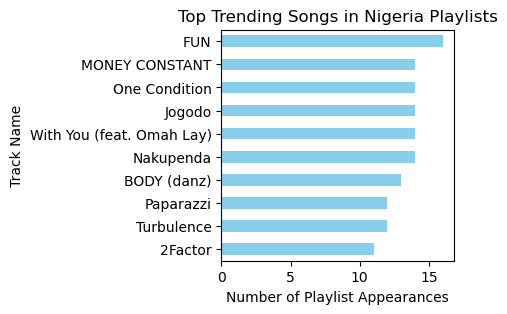

In [148]:

# Aggregate total playlist appearances per track
top_tracks = (
    recurring_songs.groupby("track_name")["playlists"]
    .sum()
    .sort_values(ascending=False)
    .head(10)  # top 15 songs
)

# Plot horizontal bar chart
top_tracks.sort_values().plot(kind="barh", figsize=(3,3), color='skyblue')
plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Track Name")
plt.title("Top Trending Songs in Nigeria Playlists")

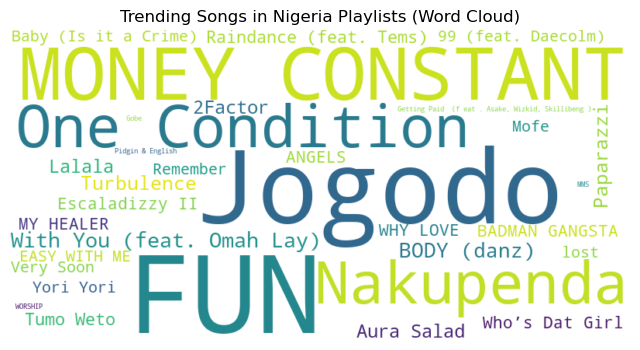

In [146]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Aggregate total playlist appearances per track
freq_dict = recurring_songs.groupby("track_name")["playlists"].sum().to_dict()

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(freq_dict)

# Display
plt.figure(figsize=(8,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Songs in Nigeria Playlists (Word Cloud)")
plt.show()

In [77]:
piano_rows = recurring_songs[recurring_songs["genre"].str.contains('piano',case=False, na=False)]

In [78]:
piano_rows

,track_id,track_name,artist,playlists,bpm,genre
84,0FU7ERQTOECwmEIaWDgdIG,BADMAN GANGSTA,Asake,10,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
128,0Q1bMs3xLQiDEeaneehdxv,Remember,Asake,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
224,0gu5Cc9YgsGVa4h7H6RyTW,Gobe,Davido,8,None,"afrobeats, afrobeat, afropop, afropiano, azont..."
276,0qlu7Te2J2BuAGFcwb3rjn,FUN,Rema,16,None,"afrobeats, afrobeat, afropop, afropiano"
319,12jMMRyPNMTNp3CRmdWMve,MONEY CONSTANT,DJ Maphorisa,14,None,"amapiano, gqom, private school piano, 3 step, ..."
325,13VXuHw3O8Yt7VwRIDqSo4,MMS,Asake,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
394,1HJr3tp2LIrvXFexwiyn7s,"Getting Paid ​(f​eat​. Asake, Wizkid, Skillibe...",Sarz,8,None,"afrobeats, afrobeat, alté, afropop, afropiano,..."
567,1p0zeYPLjmIGtw1DzmshZO,Nakupenda,TxC,14,None,"amapiano, afropiano, gqom, afrobeats, 3 step"
598,1w8lSGDuMUgRh7rygMp7VB,Mofe,Mavo,9,None,"alté, afrobeats, afropiano, afrobeat, amapiano"
723,2IocWgGPI0o6rmRDeb7Zrz,Very Soon,BNXN,9,None,"afrobeats, afrobeat, afropop, afro adura, afro..."


# trying for zimbabwe songs

In [79]:
# Search broadly for Nigeria playlists
zim_search_results = sp.search(q="Zimbabwe", type="playlist", limit=50)

Couldn't read cache at: .cache
Couldn't write token to cache at: .cache


In [80]:
zim_all_tracks = []
zim_items = zim_search_results.get("playlists", {}).get("items", [])
if zim_items:
    for pl in zim_items:
        if pl:  # make sure pl is not None
            print("Name:", pl.get("name"))
            print("ID:", pl.get("id"))
            print("Owner:", pl.get("owner", {}).get("display_name"))
            print("---")
else:
    print("No playlists found for query.")

Name: Zimbabwean Top 100🔥 Zimbabwe Trending  Hits Songs 2026 Zimbabwean Hits 2026  Zimbabwe Mix  2026 Zim 
ID: 62pclye6xpbTx1idsqACM8
Owner: GandaChartsRadar
---
Name: Best of Zimbabwean songs
ID: 0xzBYNXv07rHW058SFACt9
Owner: Anele S Mkwananzi
---
Name: Zim Top Hits - Trending Hits  in Zimbabwe Top 50 Songs Today
ID: 3d5WGIaXFCV48ytRrocPw6
Owner: towernter
---
Name: Zimbabwe Trending Hits  2026 🇿🇼  Zimbabwean Top 50 Songs 2026
ID: 6izBhalckMlY2u712t2A29
Owner: GandaChartsRadar
---
Name:  Zimbabwean All Time Greatest  Songs from Zim
ID: 1xF70bIpfizrasfna2iIS1
Owner: Blessed Chasara
---
Name: Best of Zimbabwean Praise and Worship
ID: 7lfbt840hscQUisQp8RdUx
Owner: Paul
---
Name: ZIM HOT SONGS🇿🇼
ID: 1fryCsgS0vtXvuo5XzBO8k
Owner: KING👑
---
Name: old school classics zimbabwe
ID: 7ErpiPah4F9zIUhqhhhMPf
Owner: zvevamwe
---
Name: Zimbabwe Trending  Hits 💯
ID: 1CSgiKVSm6QK4yRiEp1yZ8
Owner: Anozivah
---
Name: Zimbabwe Trending Hits  2026 🇿🇼  Zimbabwean Top 50 Songs
ID: 27dk4aUY9RtqoTSIbiXJRh
Own

In [81]:
zim_playlist_ids = [pl["id"] for pl in zim_items if pl]  # collect IDs automatically
# Step 2: Collect tracks from each playlist
for pid in zim_playlist_ids:
    results = sp.playlist_items(pid, limit=100)
    for zim_item in results["items"]:
        zim_track = zim_item["track"]
        if zim_track:
            zim_all_tracks.append({
                "track_id": zim_track["id"],
                "track_name": zim_track["name"],
                "artist": zim_track["artists"][0]["name"],
                "playlist_id": pid
            })

zim_df = pd.DataFrame(zim_all_tracks)

# Step 3: Find recurring tracks (appearing in 2+ playlists)
zim_recurring = (
    zim_df.groupby(["track_id", "track_name", "artist"])
      .agg(playlists=("playlist_id", "nunique"))
      .reset_index()
)
zim_recurring_songs = zim_recurring[zim_recurring["playlists"] > 7]

# Step 4: Enrich with BPM and genre
zim_bpm_list, zim_genre_list = [], []

for tid in zim_recurring_songs["track_id"]:
    # BPM
    try:
        zim_features = sp.audio_features([tid])[0]
        zim_bpm = zim_features["tempo"] if features else None
    except Exception:
        zim_bpm = None

    # Genre (artist-level)
    try:
        zim_track_info = sp.zim_track(tid)
        zim_artist_id = zim_track_info["artists"][0]["id"]
        zim_artist_info = sp.artist(zim_artist_id)
        zim_genres = ", ".join(zim_artist_info.get("genres", []))
    except Exception:
        zim_genres = None

    zim_bpm_list.append(bpm)
    zim_genre_list.append(genres)

zim_recurring_songs["bpm"] = zim_bpm_list
zim_recurring_songs["genre"] = zim_genre_list

# Step 5: Save to CSV
zim_recurring_songs.to_csv("recurring_zim_songs_with_bpm_genre.csv", index=False)

print(zim_recurring_songs.head())

Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at:

                   track_id         track_name        artist  playlists   bpm  \
180  0XF4EGJKoC5JJ8jk5whpxM    Pane Acha Chema       Nutty O          9  None   
346  12lt3GntWxqRl4qYvccAot  Kumba Hakuna Basa      Voltz JT          8  None   
651  1xSConsxArFrSFpbPap0Gm    Jolai neNgirozi       Oriyano          9  None   
801  2SW48mIzMDgQwei8F7lwCN             Vendor  Shona Prince          8  None   
818  2Viamb91EZkk21lJYDeZgN             Makoti  Atenda chinx          8  None   

                                                 genre  
180  afrobeats, afrobeat, afropiano, afro adura, af...  
346  afrobeats, afrobeat, afropiano, afro adura, af...  
651  afrobeats, afrobeat, afropiano, afro adura, af...  
801  afrobeats, afrobeat, afropiano, afro adura, af...  
818  afrobeats, afrobeat, afropiano, afro adura, af...  


C:\Users\HP\AppData\Local\Temp\ipykernel_18156\403922430.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zim_recurring_songs["bpm"] = zim_bpm_list
C:\Users\HP\AppData\Local\Temp\ipykernel_18156\403922430.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zim_recurring_songs["genre"] = zim_genre_list


In [82]:
zim_recurring_songs

,track_id,track_name,artist,playlists,bpm,genre
180,0XF4EGJKoC5JJ8jk5whpxM,Pane Acha Chema,Nutty O,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
346,12lt3GntWxqRl4qYvccAot,Kumba Hakuna Basa,Voltz JT,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
651,1xSConsxArFrSFpbPap0Gm,Jolai neNgirozi,Oriyano,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
801,2SW48mIzMDgQwei8F7lwCN,Vendor,Shona Prince,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
818,2Viamb91EZkk21lJYDeZgN,Makoti,Atenda chinx,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
828,2XDc0pwXNz4rf1502i3zOL,Impossible,Master H,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
911,2m5gN6yE9MvtYkkSiidPl7,KUNGE RHEDHIYO,Nashie Zim,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1301,3wRG8OIoW8Zk8Nat9H3mNX,Tsvodi,Nyasha David,10,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1317,3yWh8ng5gERgylNDPQpaxf,Tinodanana,Jnr Spragga,12,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1339,43zsxB2DRl7SuEuqZmS0tC,Ndiye,Leo Magozz,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."


In [91]:
zim_recurring_songs = zim_recurring_songs.sort_values(
    by="playlists",
    ascending=False
)

In [92]:
zim_recurring_songs

,track_id,track_name,artist,playlists,bpm,genre
1317,3yWh8ng5gERgylNDPQpaxf,Tinodanana,Jnr Spragga,12,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1891,5kEpMAvRLmHU2ALZhl4ysM,Too Much,Nutty O,11,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1301,3wRG8OIoW8Zk8Nat9H3mNX,Tsvodi,Nyasha David,10,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
180,0XF4EGJKoC5JJ8jk5whpxM,Pane Acha Chema,Nutty O,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
651,1xSConsxArFrSFpbPap0Gm,Jolai neNgirozi,Oriyano,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
828,2XDc0pwXNz4rf1502i3zOL,Impossible,Master H,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1339,43zsxB2DRl7SuEuqZmS0tC,Ndiye,Leo Magozz,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
346,12lt3GntWxqRl4qYvccAot,Kumba Hakuna Basa,Voltz JT,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
801,2SW48mIzMDgQwei8F7lwCN,Vendor,Shona Prince,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
818,2Viamb91EZkk21lJYDeZgN,Makoti,Atenda chinx,8,None,"afrobeats, afrobeat, afropiano, afro adura, af..."


Text(0.5, 1.0, 'Top Trending Songs in Zimbabwe Playlists')

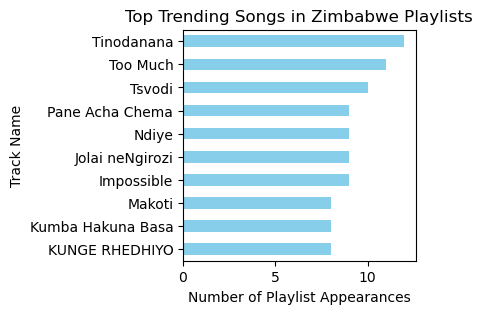

In [145]:

# Aggregate total playlist appearances per track
top_tracks = (
    zim_recurring_songs.groupby("track_name")["playlists"]
    .sum()
    .sort_values(ascending=False)
    .head(10)  # top 15 songs
)

# Plot horizontal bar chart
top_tracks.sort_values().plot(kind="barh", figsize=(3,3), color='skyblue')
plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Track Name")
plt.title("Top Trending Songs in Zimbabwe Playlists")

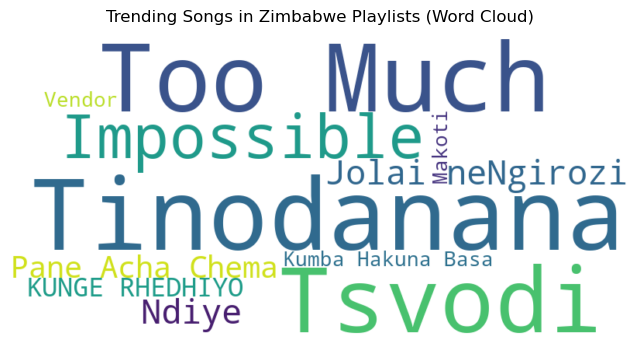

In [133]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Aggregate total playlist appearances per track
freq_dict = zim_recurring_songs.groupby("track_name")["playlists"].sum().to_dict()

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(freq_dict)

# Display
plt.figure(figsize=(8,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Songs in Zimbabwe Playlists (Word Cloud)")
plt.show()

# trying for ghana songs

In [97]:
# Search broadly for Nigeria playlists
gha_search_results = sp.search(q="Ghana", type="playlist", limit=50)

Couldn't read cache at: .cache
Couldn't write token to cache at: .cache


In [98]:
gha_all_tracks = []
gha_items = gha_search_results.get("playlists", {}).get("items", [])
if gha_items:
    for pl in gha_items:
        if pl:  # make sure pl is not None
            print("Name:", pl.get("name"))
            print("ID:", pl.get("id"))
            print("Owner:", pl.get("owner", {}).get("display_name"))
            print("---")
else:
    print("No playlists found for query.")

Name: Ghana Music 🇬🇭 
ID: 4eZdaHHGBu8RV0dDs15XMB
Owner: Garethgk
---
Name: 🇬🇭 🇬🇭GHANA TOP HITS 🇬🇭🇬🇭| AFROBEATS - 2025 (GHANA MUSIC | AFROBEATS | AFRICAN HEAT| KIDI| BLACK SHERIFF)
ID: 4t5QcqXgA5gmtomjxt774E
Owner: DJ Boat
---
Name: Ghana Independence🇬🇭
ID: 2Jp0tGx7eKnrNy9FFebCf4
Owner: richy🧚🏾‍♀️
---
Name: Ghana Hits 2026 🇬🇭 Afrobeat [Ghana Music]  
ID: 5sEUHGFI4Rf2hJsbCUPxUp
Owner: AfroDisport
---
Name: Top 100: Ghana on Spotify 2026
ID: 3gOj9RtbFhwfpk0jQsZVkp
Owner: Robbilicious
---
Name: Old Ghana Songs 🇬🇭
ID: 3EV6EAk4bxEvMUHmtt73Kp
Owner: atoffey
---
Name: Ghana Independence Day  Mix  Classics 🇬🇭
ID: 1WjQ20wDUQDYnkf6fYJxaD
Owner: Real GH Music
---
Name: Ghana Party Mix 🇬🇭
ID: 2EaYQXxLM3CGH3tqn0D7ZV
Owner: GeraldAG
---
Name: GHANA GOSPEL PRAISES
ID: 05FygT5pUaYhSn3vvun4Yj
Owner: Elorm
---
Name: Ghanaian highlife/old school mix🇬🇭
ID: 4ZWlQj8MAnqzkqjSh59Ue5
Owner: Ghanafuo_fie
---
Name: Ghana Music 2026 Mix - Top Hit Songs in Ghana 2026 (Ghana Songs Mix 2026)
ID: 47IDSMcsOyWIIBBF4C7PU

In [101]:
gha_playlist_ids = [pl["id"] for pl in gha_items if pl]  # collect IDs automatically
# Step 2: Collect tracks from each playlist
for pid in gha_playlist_ids:
    results = sp.playlist_items(pid, limit=100)
    for gha_item in results["items"]:
        gha_track = gha_item["track"]
        if gha_track:
            gha_all_tracks.append({
                "track_id": gha_track["id"],
                "track_name": gha_track["name"],
                "artist": gha_track["artists"][0]["name"],
                "playlist_id": pid
            })

gha_df = pd.DataFrame(gha_all_tracks)

# Step 3: Find recurring tracks (appearing in 2+ playlists)
gha_recurring = (
    gha_df.groupby(["track_id", "track_name", "artist"])
      .agg(playlists=("playlist_id", "nunique"))
      .reset_index()
)
gha_recurring_songs = gha_recurring[gha_recurring["playlists"] > 2]

# Step 4: Enrich with BPM and genre
gha_bpm_list, gha_genre_list = [], []

for tid in gha_recurring_songs["track_id"]:
    # BPM
    try:
        gha_features = sp.audio_features([tid])[0]
        gha_bpm = gha_features["tempo"] if features else None
    except Exception:
        gha_bpm = None

    # Genre (artist-level)
    try:
        gha_track_info = sp.gha_track(tid)
        gha_artist_id = gha_track_info["artists"][0]["id"]
        gha_artist_info = sp.artist(gha_artist_id)
        gha_genres = ", ".join(gha_artist_info.get("genres", []))
    except Exception:
        gha_genres = None

    gha_bpm_list.append(bpm)
    gha_genre_list.append(genres)

gha_recurring_songs["bpm"] = gha_bpm_list
gha_recurring_songs["genre"] = gha_genre_list

# Step 5: Save to CSV
gha_recurring_songs.to_csv("recurring_gha_songs_with_bpm_genre.csv", index=False)

print(gha_recurring_songs.head())

Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at: .cache
Couldn't read cache at: .cache
Couldn't write token to cache at:

                  track_id                                 track_name  \
1   005USYYcLUzo53W5AZPBC7                                    Sponsor   
9   01VOoRJ86VrIIPPlMlJ06Y                                    Selfish   
27  04qEuAt4TR3p2KQlJecNsu                                     Ekorso   
35  05TO59iGEPsnevlvN8t3cK  Odo Pa (feat. Asamoah Gyan & Kofi Kinata)   
39  06K0U2HojUucVXNMaQFUDv                                  Kwaadonto   

                artist  playlists   bpm  \
1                Ebony          3  None   
9         King Promise          6  None   
27          Kofi Jamar          3  None   
35    Castro Destroyer          9  None   
39  Kaakyire K. Appiah          3  None   

                                                genre  
1   afrobeats, afrobeat, afropiano, afro adura, af...  
9   afrobeats, afrobeat, afropiano, afro adura, af...  
27  afrobeats, afrobeat, afropiano, afro adura, af...  
35  afrobeats, afrobeat, afropiano, afro adura, af...  
39  afrobeats, afrobea

C:\Users\HP\AppData\Local\Temp\ipykernel_18156\100456527.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gha_recurring_songs["bpm"] = gha_bpm_list
C:\Users\HP\AppData\Local\Temp\ipykernel_18156\100456527.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gha_recurring_songs["genre"] = gha_genre_list


In [102]:
gha_recurring_songs

,track_id,track_name,artist,playlists,bpm,genre
1,005USYYcLUzo53W5AZPBC7,Sponsor,Ebony,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
9,01VOoRJ86VrIIPPlMlJ06Y,Selfish,King Promise,6,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
27,04qEuAt4TR3p2KQlJecNsu,Ekorso,Kofi Jamar,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
35,05TO59iGEPsnevlvN8t3cK,Odo Pa (feat. Asamoah Gyan & Kofi Kinata),Castro Destroyer,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
39,06K0U2HojUucVXNMaQFUDv,Kwaadonto,Kaakyire K. Appiah,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
...,...,...,...,...,...,...
2419,7g7xysGXIN9YwwgpKhfV1Z,Violence (feat. Kweku Smoke),Sarkodie,4,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
2459,7oTOQksidsMI5biGbCS0hB,Odo nwom,Kofi Nti,7,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
2505,7xujnLnBsxgby94GzXdPVi,Asew,Bisa Kdei,5,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
2512,7zWTmSyDPBGYHC3vex49jI,Wayε Me Yie,Piesie Esther,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."


In [103]:
gha_recurring_songs = gha_recurring_songs.sort_values(
    by="playlists",
    ascending=False
)

In [104]:
gha_recurring_songs

,track_id,track_name,artist,playlists,bpm,genre
35,05TO59iGEPsnevlvN8t3cK,Odo Pa (feat. Asamoah Gyan & Kofi Kinata),Castro Destroyer,9,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
2276,76OgQukE55wL78J77Vl5rp,Wish Me Well,Kuami Eugene,7,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
671,1tvi8tv0eykhNcV1WtaIqO,Move Back,5five,7,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
2459,7oTOQksidsMI5biGbCS0hB,Odo nwom,Kofi Nti,7,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
378,12jJRu9yInIX7oTxoXtM0S,Lomo Lomo,KiDi,7,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
...,...,...,...,...,...,...
1024,320cXn7htYGuAzNyxLDs3M,Rent Free,Gyakie,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1038,35bum2xpiOin7dJbziCXvg,Bottom of My Heart,Lucky Mensah,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1049,37nExiid2iQtQzCJfUzohy,Laho,Shallipopi,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."
1053,38phUOSqABmZbQwFVzQ1QZ,Nyame Do Me,Isaac Ampong,3,None,"afrobeats, afrobeat, afropiano, afro adura, af..."


In [107]:
gha_recurring_songs[gha_recurring_songs["track_name"] == "Kakalika"]

,track_id,track_name,artist,playlists,bpm,genre
636,1p5F0slR5AF49EDX5o125x,Kakalika,DopeNation,6,None,"afrobeats, afrobeat, afropiano, afro adura, af..."


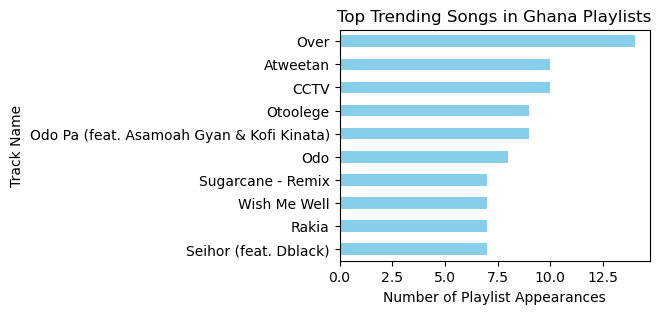

In [139]:
import matplotlib.pyplot as plt

# Aggregate total playlist appearances per track
top_tracks = (
    gha_recurring_songs.groupby("track_name")["playlists"]
    .sum()
    .sort_values(ascending=False)
    .head(10)  # top 15 songs
)

# Plot horizontal bar chart
top_tracks.sort_values().plot(kind="barh", figsize=(4,3), color='skyblue')
plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Track Name")
plt.title("Top Trending Songs in Ghana Playlists")
plt.show()

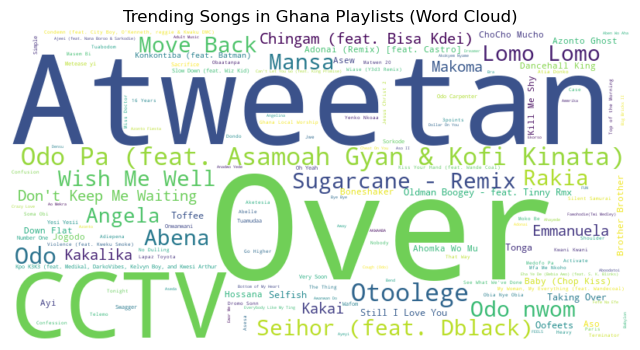

In [134]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Aggregate total playlist appearances per track
freq_dict = gha_recurring_songs.groupby("track_name")["playlists"].sum().to_dict()

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(freq_dict)

# Display
plt.figure(figsize=(8,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Songs in Ghana Playlists (Word Cloud)")
plt.show()

In [122]:
 = gha_recurring_songs.merge(recurring_songs, on="track_name")

In [123]:
naija_gha_common_songs

,track_id_x,track_name,artist_x,playlists_x,bpm_x,genre_x,track_id_y,artist_y,playlists_y,bpm_y,genre_y
0,1tBfoI9tFVl8ampIRG4eTr,Very Soon,Fameye,5,None,"afrobeats, afrobeat, afropiano, afro adura, af...",2IocWgGPI0o6rmRDeb7Zrz,BNXN,9,None,"afrobeats, afrobeat, afropop, afro adura, afro..."
1,2njWzPDRRhsXOUhiA42e62,Jogodo,Wizkid,5,None,"afrobeats, afrobeat, afropiano, afro adura, af...",2njWzPDRRhsXOUhiA42e62,Wizkid,14,None,"afrobeats, afrobeat, afropop, azonto, afroswin..."
2,5GyaXqMfcIGHfmTUITFacS,With You (feat. Omah Lay),Davido,3,None,"afrobeats, afrobeat, afropiano, afro adura, af...",5GyaXqMfcIGHfmTUITFacS,Davido,14,None,"afrobeats, afrobeat, afropop, afropiano, azont..."
3,12jMMRyPNMTNp3CRmdWMve,MONEY CONSTANT,DJ Maphorisa,3,None,"afrobeats, afrobeat, afropiano, afro adura, af...",12jMMRyPNMTNp3CRmdWMve,DJ Maphorisa,14,None,"amapiano, gqom, private school piano, 3 step, ..."
4,1p0zeYPLjmIGtw1DzmshZO,Nakupenda,TxC,3,None,"afrobeats, afrobeat, afropiano, afro adura, af...",1p0zeYPLjmIGtw1DzmshZO,TxC,14,None,"amapiano, afropiano, gqom, afrobeats, 3 step"
5,0qlu7Te2J2BuAGFcwb3rjn,FUN,Rema,3,None,"afrobeats, afrobeat, afropiano, afro adura, af...",0qlu7Te2J2BuAGFcwb3rjn,Rema,16,None,"afrobeats, afrobeat, afropop, afropiano"
6,1w8lSGDuMUgRh7rygMp7VB,Mofe,Mavo,3,None,"afrobeats, afrobeat, afropiano, afro adura, af...",1w8lSGDuMUgRh7rygMp7VB,Mavo,9,None,"alté, afrobeats, afropiano, afrobeat, amapiano"
7,3oTuTpF1F3A7rEC6RKsMRz,Raindance (feat. Tems),Dave,3,None,"afrobeats, afrobeat, afropiano, afro adura, af...",3oTuTpF1F3A7rEC6RKsMRz,Dave,11,None,"grime, uk grime, uk drill, drill"


COMMON SONGS IN GHANA AND NIGERIA PLAY LIST

In [124]:
naja_gha_common_songs = recurring_songs[recurring_songs["track_name"].isin(gha_recurring_songs["track_name"])][["track_name", "artist"]]

In [125]:
naja_gha_common_songs

,track_name,artist
276,FUN,Rema
1642,With You (feat. Omah Lay),Davido
870,Jogodo,Wizkid
319,MONEY CONSTANT,DJ Maphorisa
567,Nakupenda,TxC
1178,Raindance (feat. Tems),Dave
723,Very Soon,BNXN
598,Mofe,Mavo


In [129]:
naja_gha_total_common = naja_gha_common_songs.shape[0]
print(naja_gha_total_common)

8


COMMON SONGS IN ZIM AND NIGERIA PLAY LIST

In [127]:
naja_zim_common_songs = recurring_songs[recurring_songs["track_name"].isin(zim_recurring_songs["track_name"])][["track_name", "artist"]]

In [128]:
naja_zim_common_songs 

,track_name,artist
